In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from xgcm import Grid
import matplotlib.gridspec as gridspec

In [2]:
ds_seq0=xr.open_dataset('Files/seq0.nc')
ds_seq2=xr.open_dataset('Files/seq2.nc')
ds_seq3=xr.open_dataset('Files/seq3.nc')
ds_scurl0=xr.open_dataset('Files/scurl0.nc')
ds_eq0=xr.open_dataset('Files/eq0.nc')
ds_eq2=xr.open_dataset('Files/eq2.nc')
ds_eq3=xr.open_dataset('Files/eq3.nc')
ds_curl0=xr.open_dataset('Files/curl0.nc')

In [4]:
ds_stats1 = xr.open_dataset('Files/ocean_geometry.nc', decode_times=False)
ds_stats1 = ds_stats1.rename({'lath' : 'yh','lonh' : 'xh','latq' : 'yq','lonq' : 'xq'}) 
grid1 = Grid(ds_seq0, coords= {'X':{'center':'xh','outer':'xq'}, 'Y':{'center':'yh','outer':'yq'}, 'Z':{'center':'zl','outer':'zi'}},periodic=['X'])

In [5]:
velocity = grid1.interp(ds_seq0.vh, 'Y')
temperature = grid1.interp(ds_seq0.temp, 'Y')

/home/mesomiso/miniconda3/envs/amoc/lib/python3.9/site-packages/xgcm/grid_ufunc.py:832: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  out_dim: grid._ds.dims[out_dim] for arg in out_core_dims for out_dim in arg


In [6]:
velocity_eq = grid1.interp(ds_eq0.vh, 'Y')
temperature_eq = grid1.interp(ds_eq0.temp, 'Y')

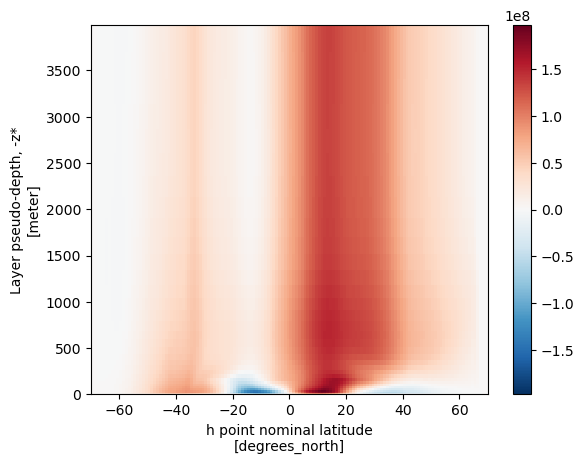

In [7]:
(ds_seq0.temp*velocity).sum('xh').cumsum('zl').plot()

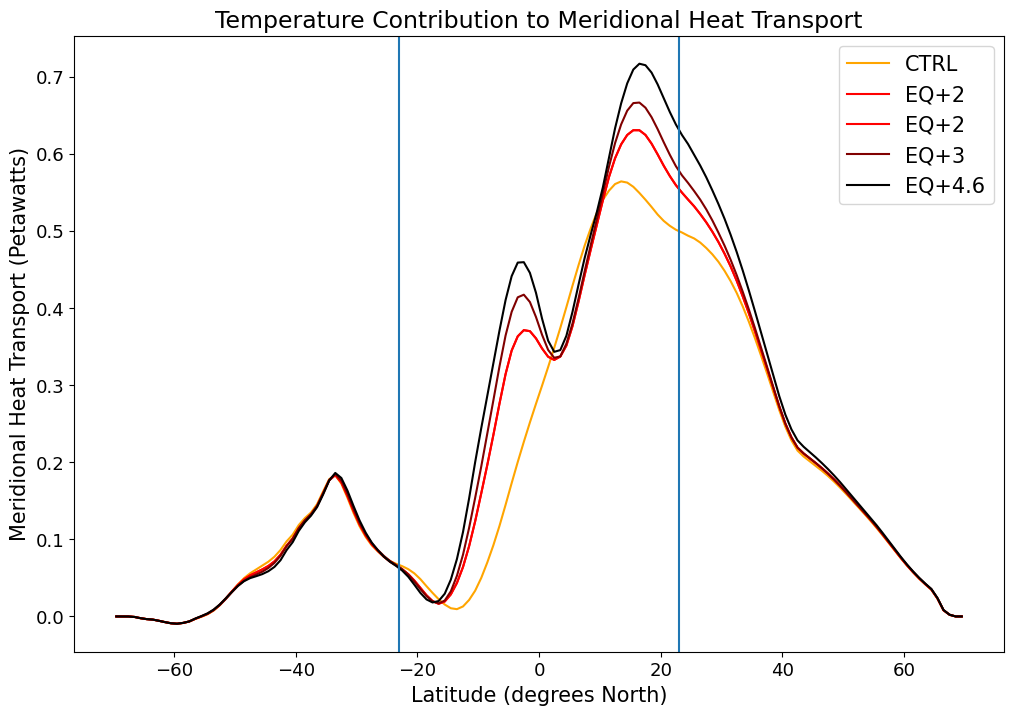

In [8]:
plt.figure(figsize=(12,8))
(((((velocity)*ds_seq0.temp)*1000*4200).sum('zl')).sum(dim='xh')*10**-15).plot(color='orange', label='CTRL')
(((((velocity)*ds_seq2.temp)*1000*4200).sum('zl')).sum(dim='xh')*10**-15).plot(color='red',label='EQ+2')
(((((velocity)*ds_seq2.temp)*1000*4200).sum('zl')).sum(dim='xh')*10**-15).plot(color='red',label='EQ+2')
(((((velocity)*ds_seq3.temp)*1000*4200).sum('zl')).sum(dim='xh')*10**-15).plot(color='maroon',label='EQ+3')
(((((velocity)*ds_scurl0.temp)*1000*4200).sum('zl')).sum(dim='xh')*10**-15).plot(color ='black', label='EQ+4.6')
# ((((velocity.sel(zl=slice(6.5, 1110))*ds_seq2.temp.sel(zl=slice(6.5, 1110))).sum('zl'))).sum(dim='xh').cumsum('yh')).plot(label='seq2')
# ((((velocity.sel(zl=slice(6.5, 1110))*ds_seq3.temp.sel(zl=slice(6.5, 1110))).sum('zl'))).sum(dim='xh').cumsum('yh')).plot(label='seq3')
# ((((velocity.sel(zl=slice(6.5, 1110))*ds_scurl0.temp.sel(zl=slice(6.5, 1110))).sum('zl'))).sum(dim='xh').cumsum('yh')).plot(label='scurl0')
plt.legend(fontsize=15)

plt.title("Temperature Contribution to Meridional Heat Transport", fontsize=17)
plt.tick_params(axis='both', labelsize=13)
plt.gca().set_xlabel('Latitude (degrees North)', fontsize=15)
plt.gca().set_ylabel('Meridional Heat Transport (Petawatts)', fontsize=15)
plt.axvline(x=23)
plt.axvline(x=-23)

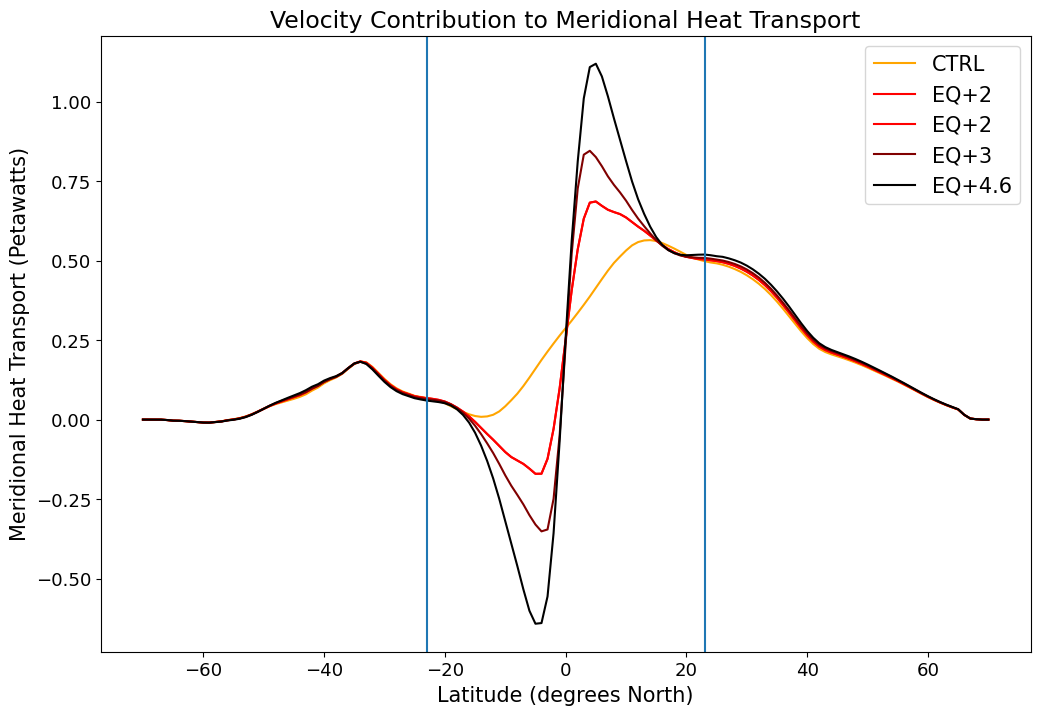

In [30]:
plt.figure(figsize=(12,8))
(((((temperature)*ds_seq0.vh)*1000*4200).sum('zl')).sum(dim='xh')*10**-15).plot(color='orange', label='CTRL')
(((((temperature)*ds_seq2.vh)*1000*4200).sum('zl')).sum(dim='xh')*10**-15).plot(color='red',label='EQ+2')
(((((temperature)*ds_seq2.vh)*1000*4200).sum('zl')).sum(dim='xh')*10**-15).plot(color='red',label='EQ+2')
(((((temperature)*ds_seq3.vh)*1000*4200).sum('zl')).sum(dim='xh')*10**-15).plot(color='maroon',label='EQ+3')
(((((temperature)*ds_scurl0.vh)*1000*4200).sum('zl')).sum(dim='xh')*10**-15).plot(color ='black', label='EQ+4.6')
# ((((velocity.sel(zl=slice(6.5, 1110))*ds_seq2.temp.sel(zl=slice(6.5, 1110))).sum('zl'))).sum(dim='xh').cumsum('yh')).plot(label='seq2')
# ((((velocity.sel(zl=slice(6.5, 1110))*ds_seq3.temp.sel(zl=slice(6.5, 1110))).sum('zl'))).sum(dim='xh').cumsum('yh')).plot(label='seq3')
# ((((velocity.sel(zl=slice(6.5, 1110))*ds_scurl0.temp.sel(zl=slice(6.5, 1110))).sum('zl'))).sum(dim='xh').cumsum('yh')).plot(label='scurl0')
plt.legend(fontsize=15)

plt.title("Velocity Contribution to Meridional Heat Transport", fontsize=17)
plt.tick_params(axis='both', labelsize=13)
plt.gca().set_xlabel('Latitude (degrees North)', fontsize=15)
plt.gca().set_ylabel('Meridional Heat Transport (Petawatts)', fontsize=15)

plt.axvline(x=23)
plt.axvline(x=-23)

plt.savefig('Images/velcontribution.png')

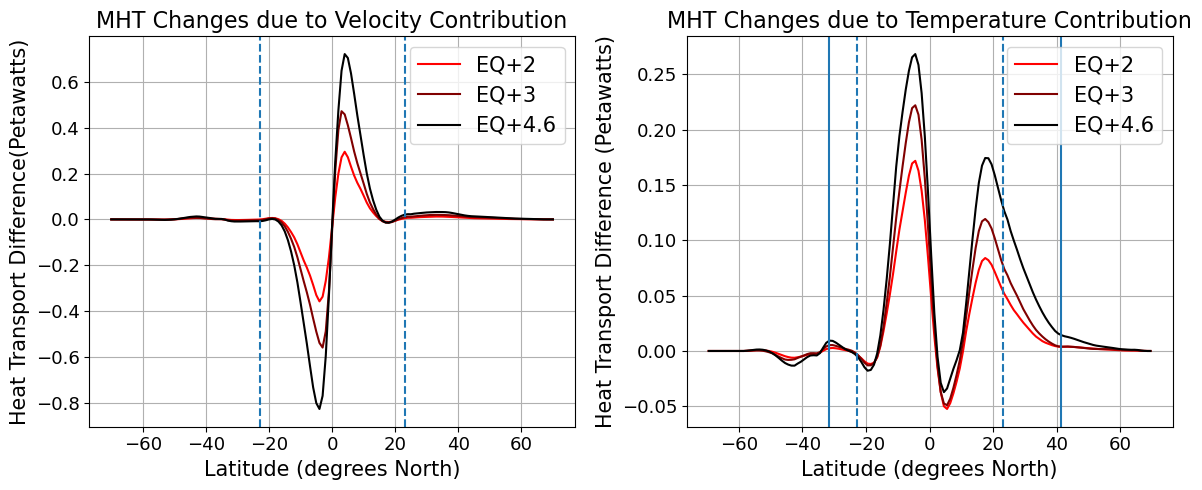

In [10]:
fig = plt.figure(figsize=(12, 5))
gs = gridspec.GridSpec(1, 2, width_ratios=[0.8, 0.8])

ax0 = fig.add_subplot(gs[0,1])
# (((((velocity)*ds_seq0.temp)*1000*4200).sum('zl')).sum(dim='xh')*10**-15).plot(ax=ax0,color='orange', label='CTRL')
((((((velocity)*ds_seq2.temp)*1000*4200).sum('zl')).sum(dim='xh')*10**-15) - (((((velocity)*ds_seq0.temp)*1000*4200).sum('zl')).sum(dim='xh')*10**-15)).plot(ax=ax0,color='red',label='EQ+2')
((((((velocity)*ds_seq3.temp)*1000*4200).sum('zl')).sum(dim='xh')*10**-15) - (((((velocity)*ds_seq0.temp)*1000*4200).sum('zl')).sum(dim='xh')*10**-15)).plot(ax=ax0,color='maroon',label='EQ+3')
((((((velocity)*ds_scurl0.temp)*1000*4200).sum('zl')).sum(dim='xh')*10**-15) - (((((velocity)*ds_seq0.temp)*1000*4200).sum('zl')).sum(dim='xh')*10**-15)).plot(ax=ax0,color ='black', label='EQ+4.6')
ax0.legend(fontsize=15)

ax0.set_title("MHT Changes due to Temperature Contribution", fontsize=16)
ax0.tick_params(axis='both', labelsize=13)
ax0.set_xlabel('Latitude (degrees North)', fontsize=15)
ax0.set_ylabel('Heat Transport Difference (Petawatts)', fontsize=15)
ax0.axvline(x=23, linestyle="--")
ax0.axvline(x=-23, linestyle ='--')
ax0.axvline(x=41.5)
# ax0.axvline(x=13.5)

ax0.axvline(x=-31.5)
plt.grid()


ax1 = fig.add_subplot(gs[0, 0])
# (((((temperature)*ds_seq0.vh)*1000*4200).sum('zl')).sum(dim='xh')*10**-15).plot(ax=ax1,color='orange', label='CTRL')
((((((temperature)*ds_seq2.vh)*1000*4200).sum('zl')).sum(dim='xh')*10**-15) - (((((temperature)*ds_seq0.vh)*1000*4200).sum('zl')).sum(dim='xh')*10**-15)).plot(ax=ax1,color='red',label='EQ+2')
((((((temperature)*ds_seq3.vh)*1000*4200).sum('zl')).sum(dim='xh')*10**-15) - (((((temperature)*ds_seq0.vh)*1000*4200).sum('zl')).sum(dim='xh')*10**-15)).plot(ax=ax1,color='maroon',label='EQ+3')
((((((temperature)*ds_scurl0.vh)*1000*4200).sum('zl')).sum(dim='xh')*10**-15) - (((((temperature)*ds_seq0.vh)*1000*4200).sum('zl')).sum(dim='xh')*10**-15)).plot(ax=ax1,color ='black', label='EQ+4.6')

ax1.legend(fontsize=15)
ax1.set_title("MHT Changes due to Velocity Contribution", fontsize=16)
ax1.tick_params(axis='both', labelsize=13)
ax1.set_xlabel('Latitude (degrees North)', fontsize=15)
ax1.set_ylabel('Heat Transport Difference(Petawatts)', fontsize=15)
ax1.axvline(x=23, linestyle="--")
ax1.axvline(x=-23, linestyle ='--')

plt.grid()
plt.tight_layout()

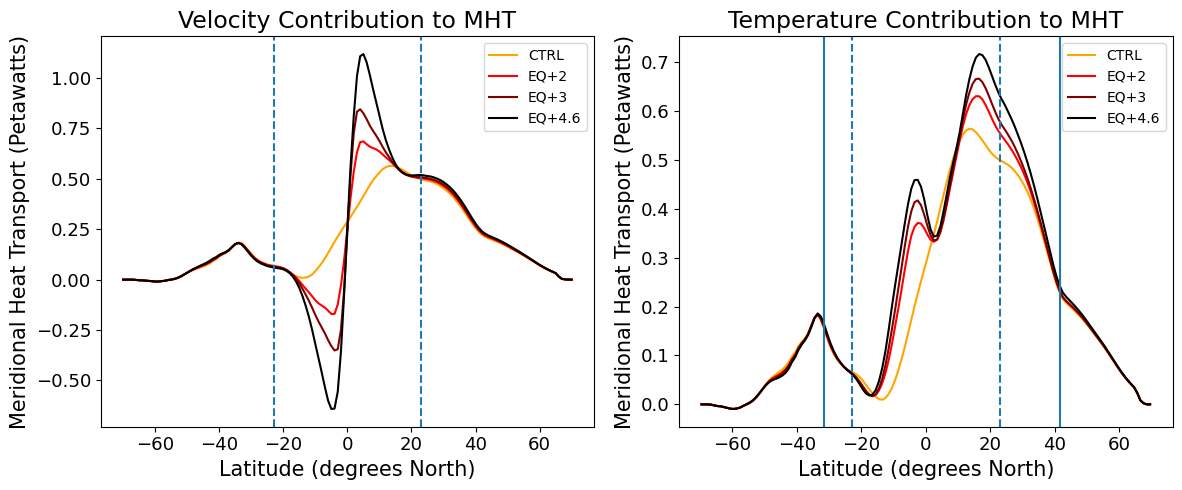

In [9]:
fig = plt.figure(figsize=(12, 5))
gs = gridspec.GridSpec(1, 2, width_ratios=[0.8, 0.8])

ax0 = fig.add_subplot(gs[0,1])
(((((velocity)*ds_seq0.temp)*1000*4200).sum('zl')).sum(dim='xh')*10**-15).plot(ax=ax0,color='orange', linestyle="-", label='CTRL')
(((((velocity)*ds_seq2.temp)*1000*4200).sum('zl')).sum(dim='xh')*10**-15).plot(ax=ax0,color='red',linestyle="-",label='EQ+2')
(((((velocity)*ds_seq3.temp)*1000*4200).sum('zl')).sum(dim='xh')*10**-15).plot(ax=ax0,color='maroon',linestyle="-",label='EQ+3')
(((((velocity)*ds_scurl0.temp)*1000*4200).sum('zl')).sum(dim='xh')*10**-15).plot(ax=ax0,color ='black', linestyle="-",label='EQ+4.6')

# (((((velocity_eq)*ds_eq0.temp)*1000*4200).sum('zl')).sum(dim='xh')*10**-15).plot(ax=ax0,color='orange', label='CTRLsym')
# (((((velocity_eq)*ds_eq2.temp)*1000*4200).sum('zl')).sum(dim='xh')*10**-15).plot(ax=ax0,color='red',label='EQsym+2')
# (((((velocity_eq)*ds_eq2.temp)*1000*4200).sum('zl')).sum(dim='xh')*10**-15).plot(ax=ax0,color='red',label='EQsym+2')
# (((((velocity_eq)*ds_eq3.temp)*1000*4200).sum('zl')).sum(dim='xh')*10**-15).plot(ax=ax0,color='maroon',label='EQsym+3')
# (((((velocity_eq)*ds_curl0.temp)*1000*4200).sum('zl')).sum(dim='xh')*10**-15).plot(ax=ax0,color ='black', label='EQsym+4.6')
ax0.legend()

ax0.set_title("Temperature Contribution to MHT", fontsize=17)
ax0.tick_params(axis='both', labelsize=13)
ax0.set_xlabel('Latitude (degrees North)', fontsize=15)
ax0.set_ylabel('Meridional Heat Transport (Petawatts)', fontsize=15)
ax0.axvline(x=23, linestyle="--")
ax0.axvline(x=-23, linestyle ='--')
# ax0.axvline(x=-31.5, linestyle ='-')
# ax0.axvline(x=41.5, linestyle ='-')

# ax0.axvline(x=41.5)
# ax0.axvline(x=-31.5)

ax1 = fig.add_subplot(gs[0, 0])
(((((temperature)*ds_seq0.vh)*1000*4200).sum('zl')).sum(dim='xh')*10**-15).plot(ax=ax1,color='orange', linestyle = "-", label='CTRL')
(((((temperature)*ds_seq2.vh)*1000*4200).sum('zl')).sum(dim='xh')*10**-15).plot(ax=ax1,color='red',linestyle = "-", label='EQ+2')
(((((temperature)*ds_seq3.vh)*1000*4200).sum('zl')).sum(dim='xh')*10**-15).plot(ax=ax1,color='maroon',linestyle = "-", label='EQ+3')
(((((temperature)*ds_scurl0.vh)*1000*4200).sum('zl')).sum(dim='xh')*10**-15).plot(ax=ax1,color ='black', linestyle = "-", label='EQ+4.6')

# (((((temperature_eq)*ds_eq0.vh)*1000*4200).sum('zl')).sum(dim='xh')*10**-15).plot(ax=ax1,color='orange', label='CTRLsym')
# (((((temperature_eq)*ds_eq2.vh)*1000*4200).sum('zl')).sum(dim='xh')*10**-15).plot(ax=ax1,color='red',label='EQsym+2')
# (((((temperature_eq)*ds_eq2.vh)*1000*4200).sum('zl')).sum(dim='xh')*10**-15).plot(ax=ax1,color='red',label='EQsym+2')
# (((((temperature_eq)*ds_eq3.vh)*1000*4200).sum('zl')).sum(dim='xh')*10**-15).plot(ax=ax1,color='maroon',label='EQsym+3')
# (((((temperature_eq)*ds_curl0.vh)*1000*4200).sum('zl')).sum(dim='xh')*10**-15).plot(ax=ax1,color ='black', label='EQsym+4.6')

ax1.legend()
ax1.set_title("Velocity Contribution to MHT", fontsize=17)
ax1.tick_params(axis='both', labelsize=13)
ax1.set_xlabel('Latitude (degrees North)', fontsize=15)
ax1.set_ylabel('Meridional Heat Transport (Petawatts)', fontsize=15)
ax1.axvline(x=23, linestyle="--")
ax1.axvline(x=-23, linestyle ='--')
ax0.axvline(x=-31.5, linestyle ='-')
ax0.axvline(x=41.5, linestyle ='-')

plt.tight_layout()

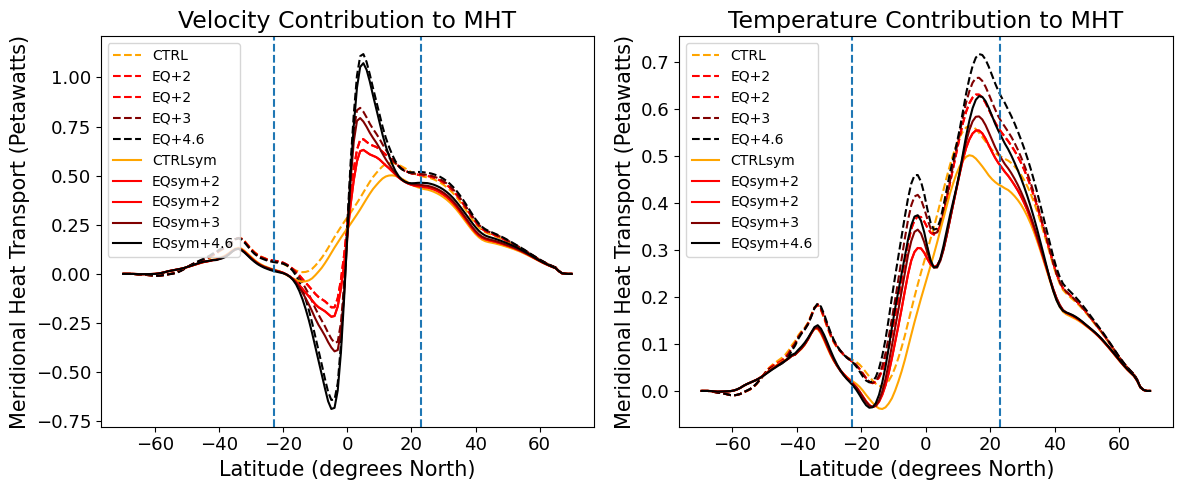

In [12]:
fig = plt.figure(figsize=(12, 5))
gs = gridspec.GridSpec(1, 2, width_ratios=[0.8, 0.8])

ax0 = fig.add_subplot(gs[0,1])
(((((velocity)*ds_seq0.temp)*1000*4200).sum('zl')).sum(dim='xh')*10**-15).plot(ax=ax0,color='orange', linestyle="--", label='CTRL')
(((((velocity)*ds_seq2.temp)*1000*4200).sum('zl')).sum(dim='xh')*10**-15).plot(ax=ax0,color='red',linestyle="--",label='EQ+2')
(((((velocity)*ds_seq2.temp)*1000*4200).sum('zl')).sum(dim='xh')*10**-15).plot(ax=ax0,color='red',linestyle="--",label='EQ+2')
(((((velocity)*ds_seq3.temp)*1000*4200).sum('zl')).sum(dim='xh')*10**-15).plot(ax=ax0,color='maroon',linestyle="--",label='EQ+3')
(((((velocity)*ds_scurl0.temp)*1000*4200).sum('zl')).sum(dim='xh')*10**-15).plot(ax=ax0,color ='black', linestyle="--",label='EQ+4.6')

(((((velocity_eq)*ds_eq0.temp)*1000*4200).sum('zl')).sum(dim='xh')*10**-15).plot(ax=ax0,color='orange', label='CTRLsym')
(((((velocity_eq)*ds_eq2.temp)*1000*4200).sum('zl')).sum(dim='xh')*10**-15).plot(ax=ax0,color='red',label='EQsym+2')
(((((velocity_eq)*ds_eq2.temp)*1000*4200).sum('zl')).sum(dim='xh')*10**-15).plot(ax=ax0,color='red',label='EQsym+2')
(((((velocity_eq)*ds_eq3.temp)*1000*4200).sum('zl')).sum(dim='xh')*10**-15).plot(ax=ax0,color='maroon',label='EQsym+3')
(((((velocity_eq)*ds_curl0.temp)*1000*4200).sum('zl')).sum(dim='xh')*10**-15).plot(ax=ax0,color ='black', label='EQsym+4.6')
ax0.legend()

ax0.set_title("Temperature Contribution to MHT", fontsize=17)
ax0.tick_params(axis='both', labelsize=13)
ax0.set_xlabel('Latitude (degrees North)', fontsize=15)
ax0.set_ylabel('Meridional Heat Transport (Petawatts)', fontsize=15)
ax0.axvline(x=23, linestyle="--")
ax0.axvline(x=-23, linestyle ='--')
# ax0.axvline(x=41.5)
# ax0.axvline(x=-31.5)

ax1 = fig.add_subplot(gs[0, 0])
(((((temperature)*ds_seq0.vh)*1000*4200).sum('zl')).sum(dim='xh')*10**-15).plot(ax=ax1,color='orange', linestyle = "--", label='CTRL')
(((((temperature)*ds_seq2.vh)*1000*4200).sum('zl')).sum(dim='xh')*10**-15).plot(ax=ax1,color='red',linestyle = "--", label='EQ+2')
(((((temperature)*ds_seq2.vh)*1000*4200).sum('zl')).sum(dim='xh')*10**-15).plot(ax=ax1,color='red',linestyle = "--", label='EQ+2')
(((((temperature)*ds_seq3.vh)*1000*4200).sum('zl')).sum(dim='xh')*10**-15).plot(ax=ax1,color='maroon',linestyle = "--", label='EQ+3')
(((((temperature)*ds_scurl0.vh)*1000*4200).sum('zl')).sum(dim='xh')*10**-15).plot(ax=ax1,color ='black', linestyle = "--", label='EQ+4.6')

(((((temperature_eq)*ds_eq0.vh)*1000*4200).sum('zl')).sum(dim='xh')*10**-15).plot(ax=ax1,color='orange', label='CTRLsym')
(((((temperature_eq)*ds_eq2.vh)*1000*4200).sum('zl')).sum(dim='xh')*10**-15).plot(ax=ax1,color='red',label='EQsym+2')
(((((temperature_eq)*ds_eq2.vh)*1000*4200).sum('zl')).sum(dim='xh')*10**-15).plot(ax=ax1,color='red',label='EQsym+2')
(((((temperature_eq)*ds_eq3.vh)*1000*4200).sum('zl')).sum(dim='xh')*10**-15).plot(ax=ax1,color='maroon',label='EQsym+3')
(((((temperature_eq)*ds_curl0.vh)*1000*4200).sum('zl')).sum(dim='xh')*10**-15).plot(ax=ax1,color ='black', label='EQsym+4.6')

ax1.legend()
ax1.set_title("Velocity Contribution to MHT", fontsize=17)
ax1.tick_params(axis='both', labelsize=13)
ax1.set_xlabel('Latitude (degrees North)', fontsize=15)
ax1.set_ylabel('Meridional Heat Transport (Petawatts)', fontsize=15)
ax1.axvline(x=23, linestyle="--")
ax1.axvline(x=-23, linestyle ='--')

plt.tight_layout()
# plt.savefig('Images/tempandvelcontri.png')